In [116]:
import numpy as np
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

In [117]:
# 載入 iris 資料集
iris = load_iris()
df = pd.DataFrame(iris["data"], columns=iris["feature_names"])
df["target"] = iris["target"]

In [118]:
df.info()
print('='*50)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


*   sepal length（花萼長度）
*   sepal width（花萼寬度）
*   petal length（花瓣長度）
*   petal width（花瓣寬度）

In [119]:
# Label Encoding
le = LabelEncoder()
df["target"] = le.fit_transform(df["target"])

In [120]:
# 切分資料集
X = df.drop("target", axis=1)
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [121]:
# 特徵縮放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [122]:
# 訓練DT模型
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

# 評估

Train Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        35
           1       1.00      1.00      1.00        35
           2       1.00      1.00      1.00        35

    accuracy                           1.00       105
   macro avg       1.00      1.00      1.00       105
weighted avg       1.00      1.00      1.00       105

Test Set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.92      0.80      0.86        15
           2       0.82      0.93      0.88        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

Train AUC: 1.000000
Test AUC: 0.933333


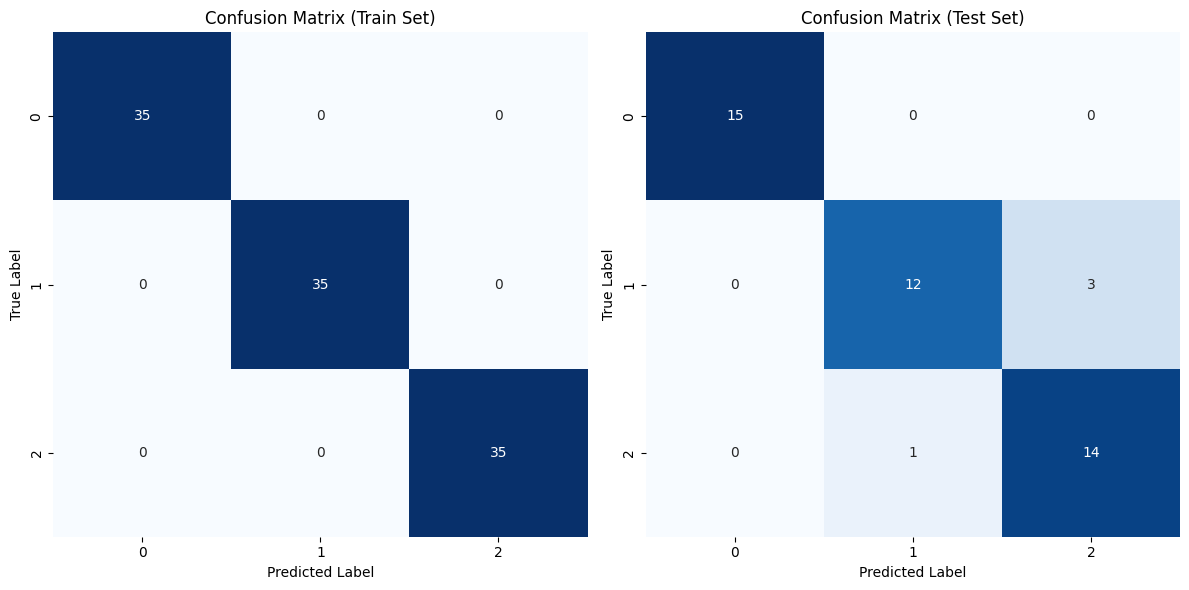

In [123]:
# 評估模型
def evaluate_model(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print("Train Set:")
    print(classification_report(y_train, y_train_pred))
    print("Test Set:")
    print(classification_report(y_test, y_test_pred))

    # 計算 AUC
    train_auc = roc_auc_score(y_train, model.predict_proba(X_train), multi_class='ovr')
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
    print(f"Train AUC: {train_auc:.6f}")
    print(f"Test AUC: {test_auc:.6f}")

    # 混淆矩陣
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.title('Confusion Matrix (Train Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.subplot(1, 2, 2)
    sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, cmap='Blues', fmt='d', cbar=False)
    plt.title('Confusion Matrix (Test Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

evaluate_model(clf, X_train_scaled, y_train, X_test_scaled, y_test)

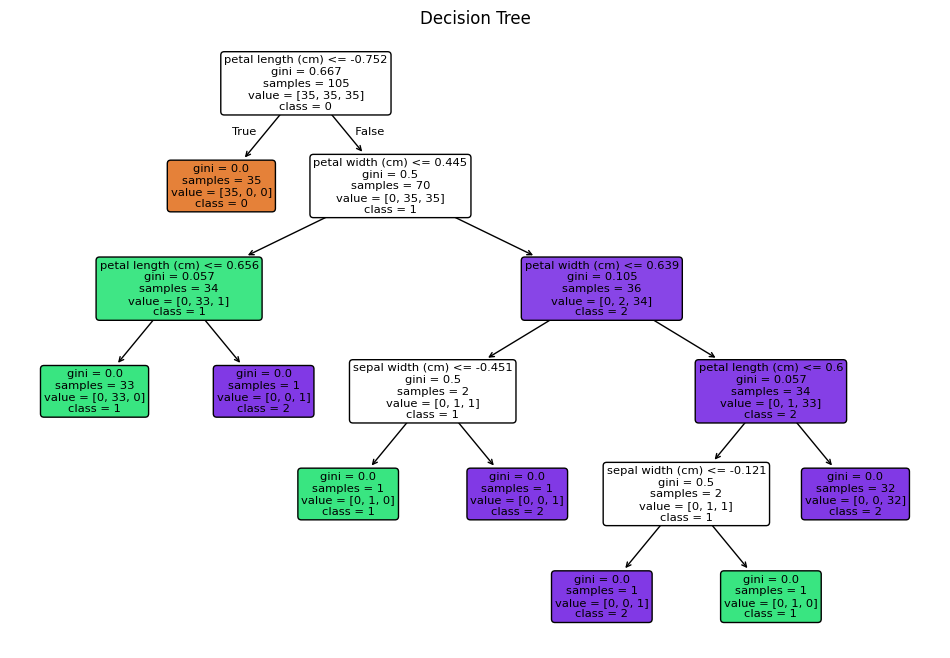

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


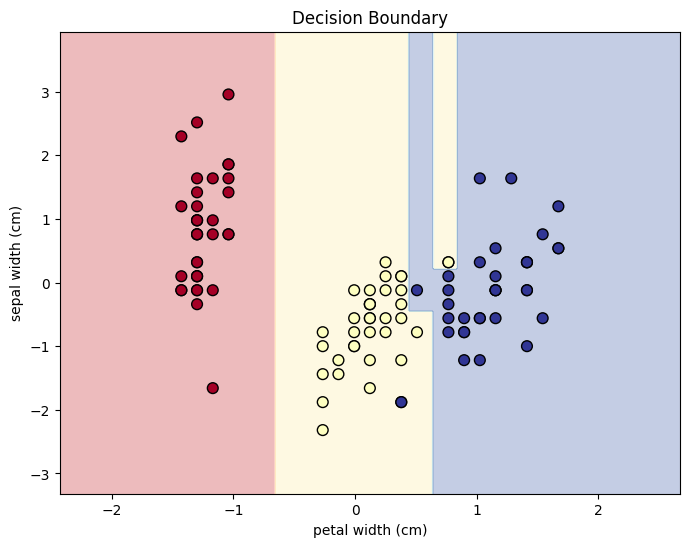

In [124]:
# 決策樹
plt.figure(figsize=(12, 8))
class_names = le.classes_.astype(str)
plot_tree(clf, filled=True, feature_names=X.columns, class_names=class_names, rounded=True)
plt.title('Decision Tree')
plt.show()

# 將 NumPy 陣列轉換為 DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

# 決策邊界圖
selected_features = ['petal width (cm)', 'sepal width (cm)']
X_train_2d = X_train_scaled_df[selected_features]
X_test_2d = X_test_scaled_df[selected_features]

# 訓練決策樹模型
clf_2d = DecisionTreeClassifier(random_state=42)
clf_2d.fit(X_train_2d, y_train)

# 創建決策邊界
h = 0.02
x_min, x_max = X_train_2d.iloc[:, 0].min() - 1, X_train_2d.iloc[:, 0].max() + 1
y_min, y_max = X_train_2d.iloc[:, 1].min() - 1, X_train_2d.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 預測決策邊界
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 繪製
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_train_2d.iloc[:, 0], X_train_2d.iloc[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolors='k', marker='o', s=60)
plt.title("Decision Boundary")
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.show()



Random Forest - Training Accuracy: 1.0000
Random Forest - Test Accuracy: 0.8889


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


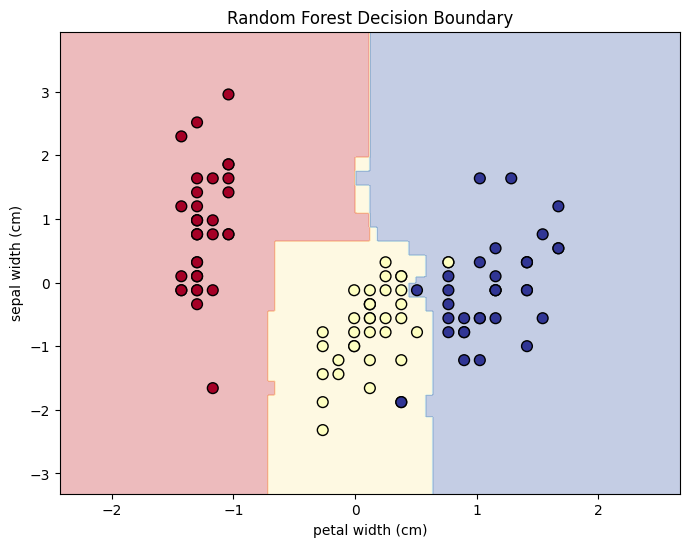

In [125]:
# 使用隨機森林訓練模型並計算準確度
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)

# accuracy
train_accuracy = accuracy_score(y_train, rf_clf.predict(X_train))
test_accuracy = accuracy_score(y_test, rf_clf.predict(X_test))
print(f"Random Forest - Training Accuracy: {train_accuracy:.4f}")
print(f"Random Forest - Test Accuracy: {test_accuracy:.4f}")

# 用全部特徵訓練，但選擇兩個特徵畫決策邊界圖
selected_features = ['petal width (cm)', 'sepal width (cm)']

# 轉換為DataFrame
X_train_2d = X_train_scaled_df[selected_features]
X_test_2d = X_test_scaled_df[selected_features]

# 訓練
rf_clf_2d = RandomForestClassifier(random_state=42)
rf_clf_2d.fit(X_train_2d, y_train)

# 創建決策邊界
h = 0.02
x_min, x_max = X_train_2d.iloc[:, 0].min() - 1, X_train_2d.iloc[:, 0].max() + 1
y_min, y_max = X_train_2d.iloc[:, 1].min() - 1, X_train_2d.iloc[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 預測決策邊界
Z = rf_clf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 繪製決策邊界
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_train_2d.iloc[:, 0], X_train_2d.iloc[:, 1], c=y_train, cmap=plt.cm.RdYlBu, edgecolors='k', marker='o', s=60)
plt.title("Random Forest Decision Boundary")
plt.xlabel(selected_features[0])
plt.ylabel(selected_features[1])
plt.show()
